# US-Leads-the-World — a quantitative teardown 🔬
### Per-market predictive HAC slopes · overnight-gap vs open→close decomposition with stale-open forensics · era decay + |move|-size conditioning · feasible-vs-phantom trade accounting · a pre/post-2010 difference test · a planted-beta synthetic control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survives_algo_era%3F: Confirmed](https://img.shields.io/badge/Survives_algo_era%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The cross-timezone spillover (Hamao-Masulis-Ng 1990; Rapach-Strauss-Zhou 2013) is a documented effect that *should* be real — so the job is an honest measurement of (a) how strong, (b) **where in the session** it lands, and (c) whether one basis point of it is capturable.

> ⚠️ **Data note.** SPY total-return adjusted; ^N225/^GDAXI/^FTSE/^AXJO **price-only** index levels. Yahoo's daily index **opens are stale** (open = previous close) on **88%** of ^FTSE days and **41%** of ^AXJO days — every open-based leg runs on live-open days only, with the share quoted. Alignment gives exactly **one execution lag** by construction (the predictor is public before the target session opens). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (as-of 2026-06-30, fingerprint `c6ad53f6345c`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from us_leads_the_world import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    BARS = data.load_real()
    PAIRS = data.build_all_pairs(BARS)
    BK = data.basket_pairs(PAIRS)
else:
    BARS = PAIRS = BK = None
print("real tape cached:", HAVE_REAL,
      "| aligned pairs:", (0 if PAIRS is None else {k: len(v) for k, v in PAIRS.items()}))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1997-01-02', 'end': '2026-06-30', 'years': 29.5, 'asof': '2026-06-30', 'fingerprint': 'c6ad53f6345c', 'cc': {'^N225': ('Nikkei 225 (Tokyo)', 0.561, 19.59, 20.0, 7415), '^GDAXI': ('DAX (Frankfurt)', 0.222, 9.21, 3.5, 7417), '^FTSE': ('FTSE 100 (London)', 0.23, 10.5, 6.2, 7417), '^AXJO': ('ASX 200 (Sydney)', 0.387, 11.18, 23.2, 7417)}, 'basket': (0.35, 14.85, 19.5, 7417), 'placebo': (0.007, 0.75, 50), 'mech': {'^N225': (0.368, 21.15, 38.2, 0.193, 6.66, 4.1, 66, 100), '^GDAXI': (0.158, 6.94, 8.6, 0.066, 4.11, 0.4, 71, 100), '^FTSE': (0.139, 7.56, 23.2, 0.147, 5.05, 2.9, 60, 12), '^AXJO': (0.194, 14.67, 27.0, 0.251, 16.53, 16.5, 50, 59)}, 'eras': [('1997-2003', 0.336, 17.56, 1760), ('2004-2010', 0.41, 15.88, 1763), ('2011-2017', 0.429, 10.99, 1761), ('2018-2026', 0.266, 4.49, 2133)], 'size': [('Q1', 0.09, 0.322, 1.83), ('Q2', 0.29, 0.259, 4.37), ('Q3', 0.57, 0.407, 10.46), ('Q4', 0.97, 0.38, 15.57), ('Q5', 2.18, 0.343, 12.51)], 'prepost': {'^N225': (0.544, 16.2, 0.584, 11.5, -0.66), '^GDAXI': (0.247, 9.0, 0.19, 4.7, 1.16), '^FTSE': (0.289, 13.5, 0.154, 4.7, 3.42), '^AXJO': (0.411, 21.3, 0.356, 5.0, 0.74), 'GLOBAL4': (0.373, 21.4, 0.321, 7.1, 1.06)}, 'feasible': {'^N225': (9.5, 7.22, 7386, -0.5, -10.5), '^GDAXI': (5.0, 3.58, 7381, -5.0, -15.0), '^AXJO': (22.8, 16.4, 4392, 12.8, 2.8)}, 'phantom': {'^N225': (48.2, 27.59), '^GDAXI': (20.9, 12.76), '^FTSE': (18.7, 14.06), '^AXJO': (35.3, 27.22)}, 'syn': [(0.0, 0.003, 0.25), (0.35, 0.354, 25.82)], 'stale': {'^FTSE': 88, '^AXJO': 41}}


real tape cached: True | aligned pairs: {'^N225': 7415, '^GDAXI': 7417, '^FTSE': 7417, '^AXJO': 7417}


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Next-session slopes: Tokyo **+0.561** (HAC **t = +19.59**), Sydney +0.387 (+11.18), London +0.230 (+10.50), Frankfurt +0.222 (+9.21); GLOBAL-4 **+0.350** (**t = +14.85**, R² = 19.5%). 50-seed shuffle placebo mean \|t\| = 0.75. |
| **Tradability** | `MIRAGE` | Gap delivers 50–71% of the slope before the first tradable print; the feasible open-entry trade nets **-0.5** (Tokyo) and **-5.0** (Frankfurt) bps/day at 5 bps one-way; the ^AXJO 'survivor' rests on a non-tradable staggered-auction open; EWJ/EWG reprice contemporaneously in US hours. |
| **Survives the algo era?** | `CONFIRMED` | GLOBAL-4 post-2010 slope **+0.321** (t = +7.1), pre/post t_diff = +1.06 (ns); Tokyo rose. Only London decayed (t_diff = +3.42). |

> 💡 In plain words: the strongest *t* on the bench, attached to zero capturable dollars — geography is a prediction machine, not a P&L machine.

## 1 · The claim, steelmanned

Let $r^{US}_t$ be SPY's day-$t$ close-to-close return (public 16:00 ET) and $r^{F}_{t+}$ the return of foreign market $F$'s **first session strictly after** date $t$ (Tokyo opens ~19:00 ET day $t$; Frankfurt/London ~03:00–04:00 ET day $t{+}1$). The spillover regression is

$$r^{F}_{t+} = \alpha + \beta\, r^{US}_t + \varepsilon_{t+},$$

with Newey-West (HAC) inference. Decompose $r^{F}_{t+}$ into the **overnight gap** $g_{t+}$ (prev close → open) and the **intraday leg** $o_{t+}$ (open → close):

- **H₁ (spillover).** $\beta > 0$, robustly, per market and pooled.
- **H₂ (mechanism).** The gap carries most of $\beta$ — the open impounds the US day.
- **H₃ (tradability).** $\mathbb{E}[\mathrm{sign}(r^{US}_t)\, o_{t+}]$ survives costs (the only executable version — the gap prints before any order can fill).
- **H₄ (persistence).** $\beta_{\text{post-2010}}$ is not significantly below $\beta_{\text{pre}}$.

We find **H₁ decisively supported** (t = 9–20), **H₂ confirmed** (gap share 50–71%, gap R² up to 38%), **H₃ rejected** (net ≤ 0 at 5 bps one-way on honestly-opened markets), **H₄ confirmed** (only London decayed). Distinct from [379-etf-lead-lag](../../379-etf-lead-lag/README.md): that was *same-timezone* intra-US lead-lag (None) — here the sessions genuinely do not overlap, so a predictive link can and does exist.

## 2 · So what? — what rides on each answer

The **time-zone alignment is the entire identification**. Because Tokyo's session lies strictly inside the window between two US closes, $r^{US}_t$ is in the information set of every trade of session $t{+}$ — the regression is predictive by construction, with no overlap contamination on the Asian legs (European sessions overlap the *next* US morning; the predictor is still strictly prior, only the error term picks up contemporaneous US noise, which HAC absorbs).

The gap/intraday split then decides everything tradable. A slope living in the gap is **an opening-auction repricing** — the textbook reason a documented, published, 35-year-old predictability can persist: there is no counterfactual P&L for arbitrageurs to compete over. The desk's rule: *a real signal is not an edge until a vehicle exists*.

## 3 · How we'd know — the protocol

- **Tape.** yfinance daily Open+Close: SPY + ^N225/^GDAXI/^FTSE/^AXJO, 1997-01-02 → 2026-06-30 (29.5 yrs), 7,415–7,417 aligned pairs/market. SPY total-return; indices price-only (labeled).
- **Alignment.** US day $t$ → first foreign session strictly after date $t$ (`searchsorted`, ≤ 7 calendar days). One execution lag by construction.
- **Inference.** OLS slope with Newey-West SE (Bartlett, `floor(4(n/100)^{2/9})` lags) on cc / gap / oc legs; HAC mean-t on strategy returns; pre/post difference t with SEs in quadrature.
- **Stale-open guard.** A day's open is *live* iff it differs from the prior close (rel. tol. 1e-6). Gap/oc/trade legs use live-open days only (^FTSE 88% stale, ^AXJO 41%).
- **Placebo.** Shuffle the US predictor, **50 seeds** (house rule ≥ 20), report mean |slope| and |t|.
- **Costs.** Feasible trade = sign(US) × next oc, one round trip/day, 5/10 bps one-way.
- **Positive control.** Synthetic world with planted gap-beta ∈ {0, 0.35}: the pipeline must recover exactly the plant, locate it in the gap, and find nothing at 0.

## 4 · The teardown

### 4a · The spillover slopes, per market + basket

Close-to-close next session on US day $t$; HAC t against the desk's t = 2 bar. The GLOBAL-4 line is the equal-weight basket of the four next-session returns.

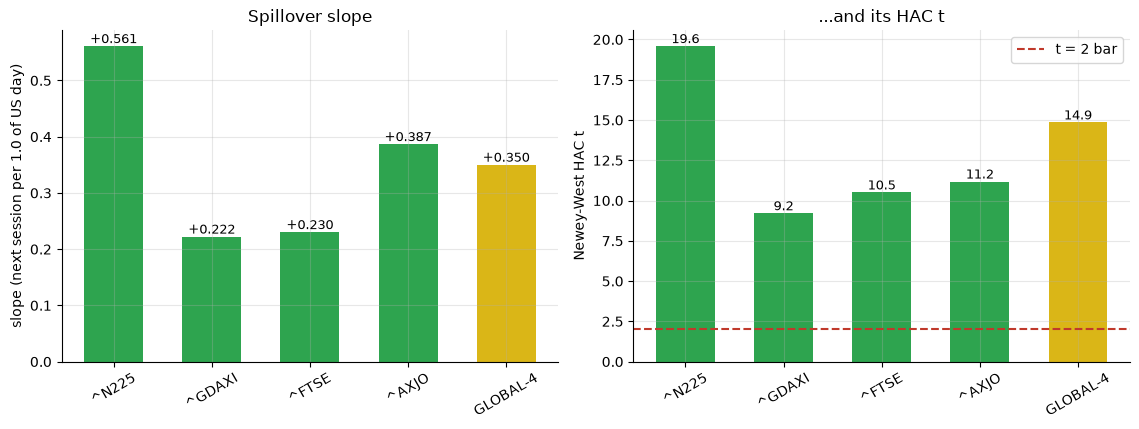

^N225     slope=+0.561  HAC t=+19.59
^GDAXI    slope=+0.222  HAC t=+9.21
^FTSE     slope=+0.230  HAC t=+10.50
^AXJO     slope=+0.387  HAC t=+11.18
GLOBAL-4  slope=+0.350  HAC t=+14.85


In [2]:
if HAVE_REAL:
    res = {tk: st.ols_hac(p['us'], p['cc']) for tk, p in PAIRS.items()}
    rb = st.ols_hac(BK['us'], BK['basket'])
    rows = [(tk, r['slope'], r['t']) for tk, r in res.items()] + [('GLOBAL-4', rb['slope'], rb['t'])]
else:
    rows = [(tk, v[1], v[2]) for tk, v in R['cc'].items()] + [('GLOBAL-4', R['basket'][0], R['basket'][1])]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
names = [r[0] for r in rows]
a1.bar(names, [r[1] for r in rows], color=[GREEN]*4+[AMBER], width=.6)
for i, r in enumerate(rows): a1.annotate(f'{r[1]:+.3f}', (i, r[1]), ha='center', va='bottom', fontsize=9)
a1.set_ylabel('slope (next session per 1.0 of US day)'); a1.set_title('Spillover slope')
a1.tick_params(axis='x', rotation=30)
a2.bar(names, [r[2] for r in rows], color=[GREEN]*4+[AMBER], width=.6)
a2.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(rows): a2.annotate(f'{r[2]:.1f}', (i, r[2]), ha='center', va='bottom', fontsize=9)
a2.set_ylabel('Newey-West HAC t'); a2.set_title('...and its HAC t'); a2.legend()
a2.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:9s} slope={r[1]:+.3f}  HAC t={r[2]:+.2f}')

> 💡 In plain words: every market clears the t = 2 bar by a factor of **4 to 10** — Tokyo at **t = +19.6** with R² = 20% is as strong as daily-frequency return prediction gets. The 50-seed shuffle placebo (next cell of `verify.py`) sits at mean |slope| = 0.0070, |t| = 0.75 — the *time link* carries everything.

### 4b · Mechanism — the gap eats the slope

Per market, the cc slope split into its gap and open→close components (live-open days only; the stale share is on the chart). The gap regression's R² is the punchline.

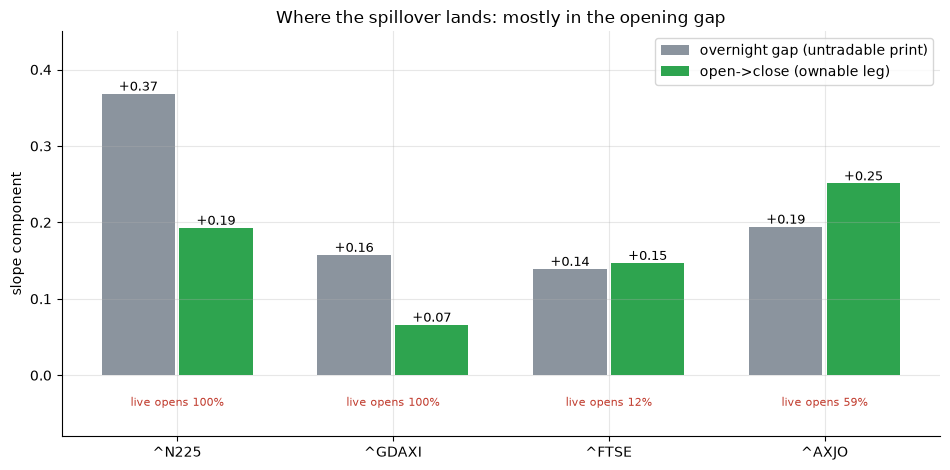

^N225   gap=+0.368 (R2 38%)  oc=+0.193  live=100%
^GDAXI  gap=+0.158 (R2 9%)  oc=+0.066  live=100%
^FTSE   gap=+0.139 (R2 23%)  oc=+0.147  live=12%
^AXJO   gap=+0.194 (R2 27%)  oc=+0.251  live=59%


In [3]:
tks = list(R['mech'].keys())
if HAVE_REAL:
    mech = {}
    for tk in tks:
        s = st.market_summary(PAIRS[tk])
        mech[tk] = (s['gap']['slope'], s['oc']['slope'], s['live_share']*100, s['gap']['r2']*100)
else:
    mech = {tk: (v[0], v[3], v[7], v[2]) for tk, v in R['mech'].items()}
x = np.arange(len(tks))
fig, ax = plt.subplots(figsize=(9.6, 4.8))
ax.bar(x-.18, [mech[t][0] for t in tks], .34, color=GREY, label='overnight gap (untradable print)')
ax.bar(x+.18, [mech[t][1] for t in tks], .34, color=GREEN, label='open->close (ownable leg)')
for i, t in enumerate(tks):
    ax.annotate(f'{mech[t][0]:+.2f}', (i-.18, mech[t][0]), ha='center', va='bottom', fontsize=9)
    ax.annotate(f'{mech[t][1]:+.2f}', (i+.18, mech[t][1]), ha='center', va='bottom', fontsize=9)
    ax.annotate(f'live opens {mech[t][2]:.0f}%', (i, -0.04), ha='center', fontsize=8, color=RED)
ax.set_xticks(x); ax.set_xticklabels(tks); ax.set_ylim(-0.08, 0.45)
ax.set_ylabel('slope component'); ax.legend()
ax.set_title('Where the spillover lands: mostly in the opening gap')
plt.tight_layout(); plt.show()
for t in tks: print(f'{t:7s} gap={mech[t][0]:+.3f} (R2 {mech[t][3]:.0f}%)  oc={mech[t][1]:+.3f}  live={mech[t][2]:.0f}%')

> 💡 In plain words: Tokyo's opening gap alone has slope +0.368 with **R² = 38%** — yesterday's S&P *is* this morning's Nikkei open, almost mechanically. The ownable open→close legs keep slopes of only +0.066–+0.193 (R² 0.4–4%) on honestly-opened markets. **Forensic note:** ^AXJO's fat oc slope (+0.251, R² 16.5%) is the staggered-auction artefact — the printed ASX open still contains unopened constituents at stale prices, so part of the 'intraday' leg is pre-open repricing. ^FTSE's split rests on 12% of days and is decorative.

### 4c · Decay and conditioning

GLOBAL-4 slope by era, and by |US-move| quintile — does the spillover fade, and does it need a big sneeze?

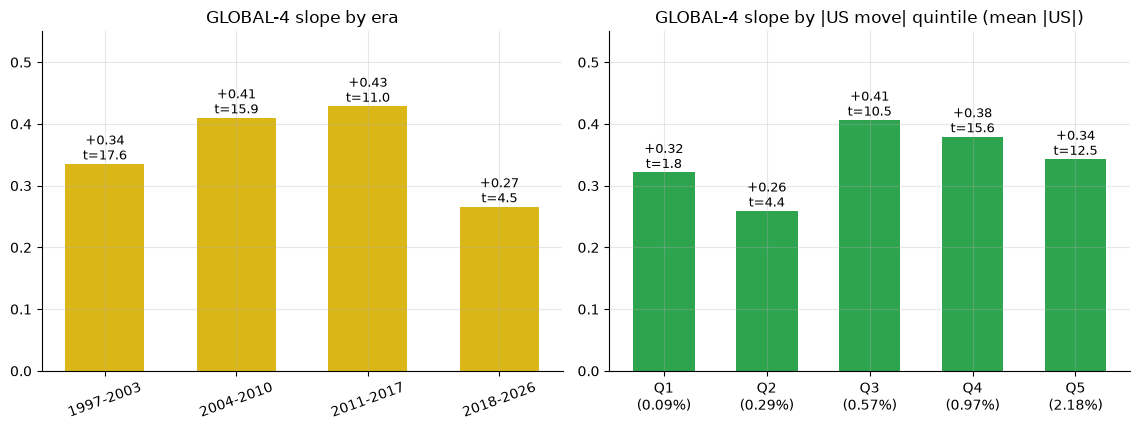

eras: [('1997-2003', 0.336, np.float64(17.56)), ('2004-2010', 0.41, np.float64(15.88)), ('2011-2017', 0.429, np.float64(10.99)), ('2018-2026', 0.266, np.float64(4.49))]
size: [('Q1', 0.322, np.float64(1.83)), ('Q2', 0.259, np.float64(4.37)), ('Q3', 0.407, np.float64(10.46)), ('Q4', 0.38, np.float64(15.57)), ('Q5', 0.343, np.float64(12.51))]


In [4]:
eras = [('1997-2003','1997','2003'),('2004-2010','2004','2010'),
        ('2011-2017','2011','2017'),('2018-2026','2018','2026')]
if HAVE_REAL:
    bk_p = BK.rename(columns={'basket':'cc'})
    er = [(r['label'], r['slope'], r['t']) for r in st.era_slopes(bk_p, eras)]
    sz = [(r['label'], r['mean_abs_us_pct'], r['slope'], r['t']) for r in st.size_conditional(BK)]
else:
    er = [(e[0], e[1], e[2]) for e in R['eras']]
    sz = R['size']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
a1.bar([e[0] for e in er], [e[1] for e in er], color=AMBER, width=.6)
for i, e in enumerate(er): a1.annotate(f'{e[1]:+.2f}\nt={e[2]:.1f}', (i, e[1]), ha='center', va='bottom', fontsize=9)
a1.set_ylim(0, .55); a1.set_title('GLOBAL-4 slope by era'); a1.tick_params(axis='x', rotation=20)
a2.bar([f'{s[0]}\n({s[1]:.2f}%)' for s in sz], [s[2] for s in sz], color=GREEN, width=.6)
for i, s in enumerate(sz): a2.annotate(f'{s[2]:+.2f}\nt={s[3]:.1f}', (i, s[2]), ha='center', va='bottom', fontsize=9)
a2.set_ylim(0, .55); a2.set_title('GLOBAL-4 slope by |US move| quintile (mean |US|)')
plt.tight_layout(); plt.show()
print('eras:', [(e[0], round(e[1],3), round(e[2],2)) for e in er])
print('size:', [(s[0], round(s[2],3), round(s[3],2)) for s in sz])

> 💡 In plain words: no monotone decay — the slope wanders 0.34 → 0.43 → 0.27 and the weakest era still posts **t = 4.49**. And it is **proportional**: the slope is flat (~0.26–0.41) across move sizes — the world reprices whatever the US did, big or small (only the tiniest-move quintile lacks the signal-to-noise to certify it).

### 4d · Tradability — phantom vs feasible, then costs

The **phantom** backtest (sign(US) held close-to-close — requires entering at a foreign close that prints *before* the US close exists) vs the **feasible** one (enter at the next open, own only open→close), gross and net.

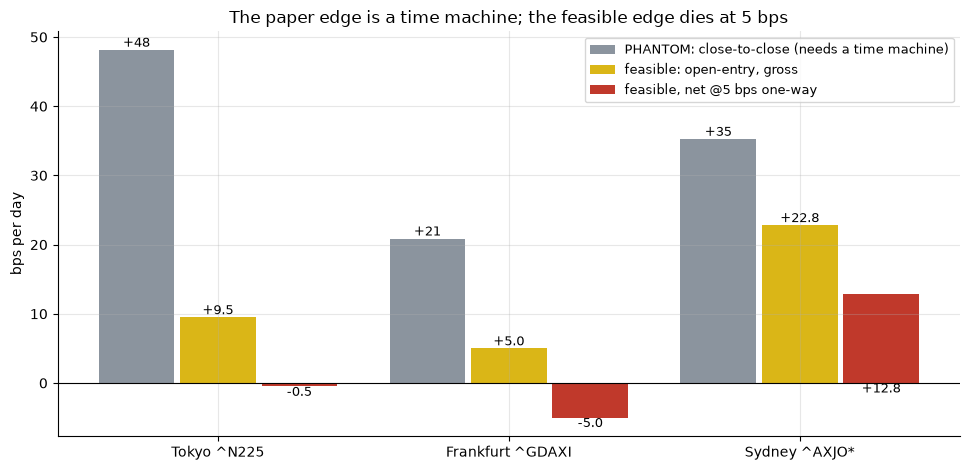

* ^AXJO net line rests on a staggered-auction open that is not a tradable price


In [5]:
tks = ['^N225', '^GDAXI', '^AXJO']
if HAVE_REAL:
    ph = [st.phantom_trade(PAIRS[tk])['gross_bps'] for tk in tks]
    fs = [st.feasible_trade(PAIRS[tk], 5.0) for tk in tks]
    gr = [r['gross_bps'] for r in fs]; n5 = [r['net_bps'] for r in fs]
else:
    ph = [R['phantom'][tk][0] for tk in tks]
    gr = [R['feasible'][tk][0] for tk in tks]; n5 = [R['feasible'][tk][3] for tk in tks]
x = np.arange(len(tks))
fig, ax = plt.subplots(figsize=(9.8, 4.8))
ax.bar(x-.28, ph, .26, color=GREY, label='PHANTOM: close-to-close (needs a time machine)')
ax.bar(x, gr, .26, color=AMBER, label='feasible: open-entry, gross')
ax.bar(x+.28, n5, .26, color=RED, label='feasible, net @5 bps one-way')
ax.axhline(0, c='k', lw=.8)
for i in range(len(tks)):
    ax.annotate(f'{ph[i]:+.0f}', (i-.28, ph[i]), ha='center', va='bottom', fontsize=9)
    ax.annotate(f'{gr[i]:+.1f}', (i, gr[i]), ha='center', va='bottom', fontsize=9)
    ax.annotate(f'{n5[i]:+.1f}', (i+.28, min(n5[i],0)), ha='center', va='top', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(['Tokyo ^N225','Frankfurt ^GDAXI','Sydney ^AXJO*'])
ax.set_ylabel('bps per day'); ax.legend(fontsize=9)
ax.set_title('The paper edge is a time machine; the feasible edge dies at 5 bps')
plt.tight_layout(); plt.show()
print('* ^AXJO net line rests on a staggered-auction open that is not a tradable price')

> 💡 In plain words: the naive backtest books **+48 bps/day** in Tokyo (t = +27.6!) — by trading at 01:00 ET on information released at 16:00 ET. The executable version keeps **+9.5 bps/day gross** (a real open-auction underreaction residue, HAC t = +7.22) and **-0.5 bps/day net** at 5 bps one-way — dead. The ^AXJO 'survivor' (+12.8 net) is credited with pre-open repricing inside a 10-minute staggered auction — not a fillable price. And the wrappers (EWJ/EWG) trade in US hours, where the spillover is contemporaneous: **no vehicle, no edge**.

### 4e · Third axis — pre/post-2010, with a t on the difference

Slopes either side of 2010-01-01 (the algo/HFT era divide), HAC SEs combined in quadrature for the difference test.

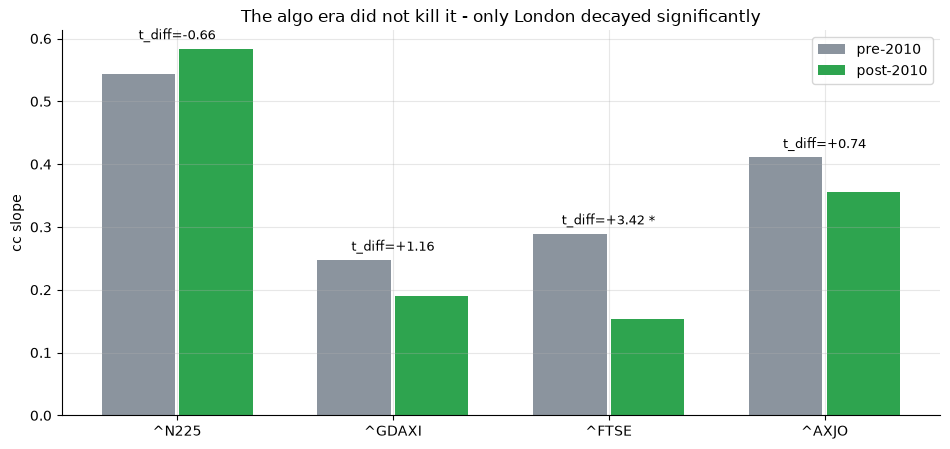

^N225   pre=+0.544 post=+0.584 t_diff=-0.66
^GDAXI  pre=+0.247 post=+0.190 t_diff=+1.16
^FTSE   pre=+0.289 post=+0.154 t_diff=+3.42
^AXJO   pre=+0.411 post=+0.356 t_diff=+0.74


In [6]:
tks = ['^N225', '^GDAXI', '^FTSE', '^AXJO']
if HAVE_REAL:
    pp = {tk: st.prepost(PAIRS[tk]) for tk in tks}
    rows = [(tk, pp[tk]['pre']['slope'], pp[tk]['post']['slope'], pp[tk]['t_diff']) for tk in tks]
else:
    rows = [(tk, R['prepost'][tk][0], R['prepost'][tk][2], R['prepost'][tk][4]) for tk in tks]
x = np.arange(len(rows))
fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.bar(x-.18, [r[1] for r in rows], .34, color=GREY, label='pre-2010')
ax.bar(x+.18, [r[2] for r in rows], .34, color=GREEN, label='post-2010')
for i, r in enumerate(rows):
    sig = ' *' if abs(r[3]) > 2 else ''
    ax.annotate(f't_diff={r[3]:+.2f}{sig}', (i, max(r[1], r[2])+.015), ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(tks); ax.set_ylabel('cc slope')
ax.set_title('The algo era did not kill it - only London decayed significantly')
ax.legend(); plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:7s} pre={r[1]:+.3f} post={r[2]:+.3f} t_diff={r[3]:+.2f}')

> 💡 In plain words: three of four markets show **no significant decay** — Tokyo's slope *rose* (+0.544 → +0.584). The basket holds +0.321 at t = +7.1 post-2010 (t_diff = +1.06, ns). The one decayer is **London** (t_diff = +3.42) — the session that most overlaps New York, where futures arbitrage can actually reach the pattern. Time-zone separation is the moat. **CONFIRMED.**

### 4f · Faithful-engine & power control — we know the truth here

A deterministic synthetic world where US day-t feeds the next foreign **gap** with a planted beta (and the intraday leg is clean noise): the pipeline must recover the plant, locate it in the gap, and find nothing at beta = 0.

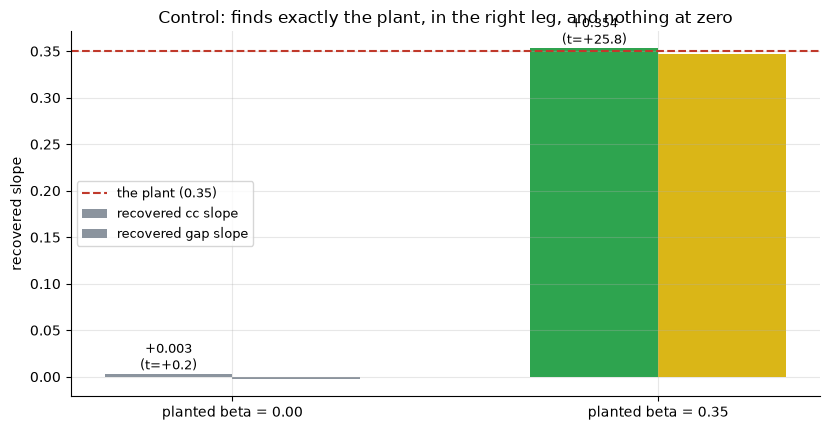

beta=0.00: cc=+0.003 (t=+0.25)  gap=-0.003  oc=+0.006
beta=0.35: cc=+0.354 (t=+25.82)  gap=+0.347  oc=+0.006


In [7]:
res = []
for beta in (0.0, 0.35):
    syn = data.synthetic_world(beta=beta, seed=634)
    p = syn['SYN_A']
    s = st.market_summary(p)
    res.append((beta, s['cc']['slope'], s['cc']['t'], s['gap']['slope'], s['oc']['slope']))
fig, ax = plt.subplots(figsize=(8.4, 4.4))
labels = [f'planted beta = {r[0]:.2f}' for r in res]
ax.bar(np.arange(2)-.15, [r[1] for r in res], .3, color=[GREY, GREEN], label='recovered cc slope')
ax.bar(np.arange(2)+.15, [r[3] for r in res], .3, color=[GREY, AMBER], label='recovered gap slope')
ax.axhline(0.35, ls='--', c=RED, label='the plant (0.35)')
for i, r in enumerate(res): ax.annotate(f'{r[1]:+.3f}\n(t={r[2]:+.1f})', (i-.15, r[1]), ha='center', va='bottom', fontsize=9)
ax.set_xticks(np.arange(2)); ax.set_xticklabels(labels)
ax.set_ylabel('recovered slope'); ax.legend(fontsize=9)
ax.set_title('Control: finds exactly the plant, in the right leg, and nothing at zero')
plt.tight_layout(); plt.show()
for r in res: print(f'beta={r[0]:.2f}: cc={r[1]:+.3f} (t={r[2]:+.2f})  gap={r[3]:+.3f}  oc={r[4]:+.3f}')

> 💡 In plain words: at beta = 0 the detector reads +0.003 (t = +0.25) — it cannot manufacture a spillover; at beta = 0.35 it reads +0.354 (t = +25.8), pinned to the gap leg with the intraday leg flat. The machinery is faithful, so the real-tape slopes are the genuine article. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `REAL`** — per-market next-session slopes +0.222 to +0.561 with HAC t = +9.2 to +19.6; GLOBAL-4 **+0.350** at **t = +14.85** (R² 19.5%); shuffle placebo |t| ≈ 0.75; flat across move sizes; every era clears the bar. No survivorship issue of consequence (four continuously computed national indices).
- **Tradability `MIRAGE`** — 50–71% of the slope is an opening-print repricing; the feasible open-entry trade nets -0.5 (Tokyo) / -5.0 (Frankfurt) bps/day at 5 bps one-way; the ^AXJO survivor line is a staggered-auction accounting ghost; EWJ/EWG reprice contemporaneously in US hours. Prediction without a vehicle.
- **Survives the algo era? `CONFIRMED`** — post-2010 GLOBAL-4 slope +0.321 (t = +7.1), difference insignificant; Tokyo strengthened; only London (the overlapping session) decayed (t_diff = +3.42).

## 6 · Going further

- **The McLean-Pontiff exemption.** Published anomalies decay because arbitrage capital attacks them. This spillover is *information flow priced at an auction* — the tradable residue is already ~zero, so publication has nothing to destroy. The London decay is the exception that proves it: where sessions overlap, futures arbitrage reaches the pattern.
- **The professional version exists — at a different cost point.** Nikkei futures on CME trade nearly 24h at ~1 bp; the open-auction underreaction residue (+9.5 bps/day gross, t = +7.2) is exactly the kind of crumb HFT market-makers harvest. That is capacity-bound plumbing, not a retail strategy — and on the honest index opens it is *already* thinner than any retail cost stack.
- **Extensions.** Add Korea/India/Brazil; regress the foreign *gap* on US futures moves during foreign hours (splitting 'US day' from 'overnight world news'); or test volatility spillover (Hamao-Masulis-Ng's second result) with a GARCH layer.

*The reproducible core is offline and deterministic; alignment gives exactly one execution lag by construction. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*